In [3]:
import pandas as pd
import numpy as np

import re
import string

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix)

!pip install tensorflow --quiet
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [4]:
# Load the Dataset

train_df = pd.read_csv("train.csv")

print("Dataset Shape :", train_df.shape)
train_df.head()

Dataset Shape : (120000, 3)


,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Class Index  120000 non-null  int64 
 1   Title        120000 non-null  object
 2   Description  120000 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.7+ MB


In [6]:
train_df.isnull().sum()

,0
Class Index,0
Title,0
Description,0


In [7]:
train_df["Class Index"].value_counts()

,count
Class Index,
3,30000
4,30000
2,30000
1,30000


In [8]:
# Combine Title and Description into a single text column

train_df["Text"] = train_df["Title"] + " " + train_df["Description"]

train_df[["Text", "Class Index"]].head()

,Text,Class Index
0,Wall St. Bears Claw Back Into the Black (Reute...,3
1,Carlyle Looks Toward Commercial Aerospace (Reu...,3
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,3
3,Iraq Halts Oil Exports from Main Southern Pipe...,3
4,"Oil prices soar to all-time record, posing new...",3


In [9]:
# Function to clean text

def clean_text(text):
    text = text.lower()                         # Convert to lowercase
    text = re.sub(r"http\S+", "", text)         # Remove URLs
    text = re.sub(r"<.*?>", "", text)           # Remove HTML tags
    text = re.sub(r"[^a-zA-Z\s]", "", text)     # Remove punctuation & numbers
    text = re.sub(r"\s+", " ", text).strip()    # Remove extra spaces
    return text

In [10]:
# Apply preprocessing

train_df["Text"] = train_df["Text"].apply(clean_text)

train_df["Text"].head()

,Text
0,wall st bears claw back into the black reuters...
1,carlyle looks toward commercial aerospace reut...
2,oil and economy cloud stocks outlook reuters r...
3,iraq halts oil exports from main southern pipe...
4,oil prices soar to alltime record posing new m...


In [11]:
# Features and Labels

X = train_df["Text"]

y = train_df["Class Index"]

print("Number of Samples :", len(X))
print("Number of Labels  :", len(y))

Number of Samples : 120000
Number of Labels  : 120000


In [12]:
# Tokenization

max_words = 20000

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X)

word_index = tokenizer.word_index

print("Total Unique Words :", len(word_index))

Total Unique Words : 90678


In [13]:
# Convert text into sequences

X_sequences = tokenizer.texts_to_sequences(X)

print("First Sequence:")
print(X_sequences[0])

First Sequence:
[393, 327, 1527, 14244, 100, 55, 2, 813, 24, 24, 1, 393, 1990, 1, 5, 1, 35, 3895, 739, 297]


In [14]:
# Pad all sequences to the same length

max_length = 100

X_padded = pad_sequences(
    X_sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("Shape of Padded Data :", X_padded.shape)

Shape of Padded Data : (120000, 100)


In [15]:
# Encode class labels

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Encoded Labels:")
print(np.unique(y_encoded))

Encoded Labels:
[0 1 2 3]


In [16]:
# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X_padded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

print("Training Labels Shape :", y_train.shape)
print("Testing Labels Shape  :", y_test.shape)

Training Data Shape : (96000, 100)
Testing Data Shape  : (24000, 100)
Training Labels Shape : (96000,)
Testing Labels Shape  : (24000,)


In [17]:
# Build the LSTM Model

model = Sequential()

# Embedding Layer
model.add(Embedding(input_dim=max_words,
                    output_dim=128,
                    input_length=max_length))

# LSTM Layer
model.add(LSTM(128))

# Dropout Layer
model.add(Dropout(0.5))

# Hidden Dense Layer
model.add(Dense(64, activation='relu'))

# Output Layer
model.add(Dense(4, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [18]:
# Compile the Model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [19]:
# Display Model Summary

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Train the LSTM Model

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 139s 183ms/step - accuracy: 0.2502 - loss: 1.3870 - val_accuracy: 0.2510 - val_loss: 1.3862
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 137s 182ms/step - accuracy: 0.2489 - loss: 1.3864 - val_accuracy: 0.2516 - val_loss: 1.3854
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 137s 182ms/step - accuracy: 0.2465 - loss: 1.3851 - val_accuracy: 0.2509 - val_loss: 1.3854
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 137s 183ms/step - accuracy: 0.3053 - loss: 1.3120 - val_accuracy: 0.7697 - val_loss: 0.6308
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 137s 183ms/step - accuracy: 0.8701 - loss: 0.4538 - val_accuracy: 0.9078 - val_loss: 0.3225
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 137s 183ms/step - accuracy: 0.9216 - loss: 0.2783 - val_accuracy: 0.9118 - val_loss: 0.2910
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 137s 183ms/step - accuracy: 0.9413 - loss: 0.2096 - val_accuracy: 0.9153 - val_loss: 0.2845
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 137s 182ms/step - accuracy: 0.9530 -

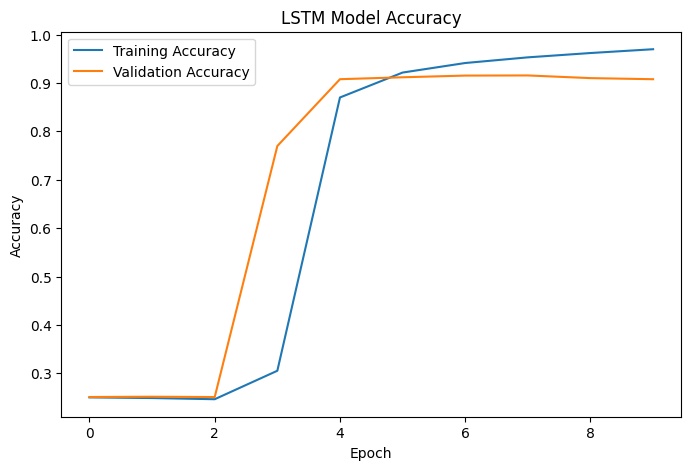

In [21]:
# Plot Accuracy

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('LSTM Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

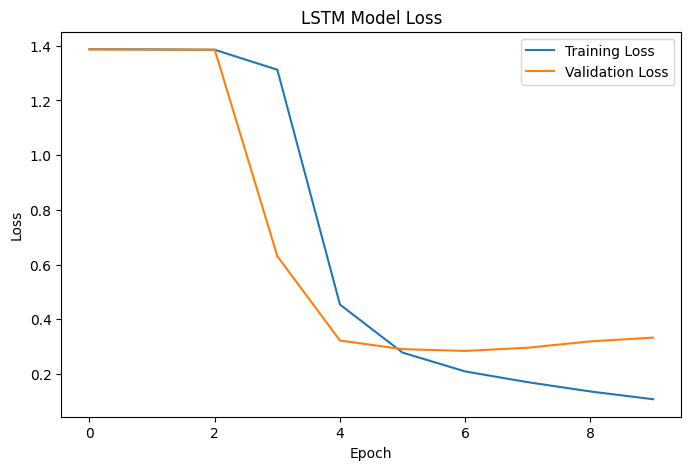

In [22]:
# Plot Loss

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('LSTM Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [23]:
# Evaluate Model

loss, accuracy = model.evaluate(X_test, y_test)

print(f"\nTest Loss     : {loss:.4f}")
print(f"Test Accuracy : {accuracy*100:.2f}%")

750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9078 - loss: 0.3331

Test Loss     : 0.3331
Test Accuracy : 90.78%
